In [48]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", context="talk")


In [49]:
BASE_DIR = Path("../")
RESULTS_DIR = BASE_DIR / "results"

RESULTS_DIR, RESULTS_DIR.exists()


(WindowsPath('../results'), True)

In [50]:
metric_files = glob.glob(str(RESULTS_DIR / "**/overall_metrics_*.csv"), recursive=True)
metric_files


['..\\results\\overall_metrics_all_models.csv',
 '..\\results\\overall_metrics_summary.csv',
 '..\\results\\linear_ar\\overall_metrics_linear.csv',
 '..\\results\\lstm\\overall_metrics_lstm.csv',
 '..\\results\\xgboost\\overall_metrics_xgb.csv']

In [51]:
rows = []

for path in metric_files:
    df = pd.read_csv(path)

    # Detect LSTM schema
    if "Model" in df.columns and "model_id" not in df.columns:
        # Example Model values: "LSTM Baseline" or "LSTM + Sentiment"
        df["model_id"] = (
            df["Model"].str.lower()
                       .str.replace(" ", "_")
                       .str.replace("+", "plus")
                       .str.replace("__", "_")
        )

        df["type"] = df["model_id"].apply(
            lambda x: "baseline" if "baseline" in x else "multimodal"
        )

        # Drop original column
        df = df.drop(columns=["Model"])

    rows.append(df)

results = pd.concat(rows, ignore_index=True)
results


,model_id,type,MSE,RMSE,MAE,R2,DirAcc,family,Family,RMSE_baseline,...,ΔRMSE,MAE_baseline,MAE_mm,ΔMAE,DirAcc_baseline,DirAcc_mm,ΔDirAcc,R2_baseline,R2_mm,ΔR2
0,lin_base_market_only,baseline,0.000212,0.014561,0.009733,-0.014180,0.488545,Linear AR,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lin_mm_multimodal,multimodal,0.000212,0.014563,0.009735,-0.014497,0.494364,Linear AR,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,lstm_baseline,baseline,0.000217,0.014728,0.009756,-0.031059,0.456286,LSTM,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,lstm_plus_sentiment,multimodal,0.000220,0.014818,0.009852,-0.043671,0.526306,LSTM,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,xgb_base_market_only,baseline,0.000227,0.015056,0.010149,-0.084375,0.488182,XGBoost,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,xgb_mm_multimodal,multimodal,0.000226,0.015020,0.010074,-0.079155,0.489455,XGBoost,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LSTM,0.014728,...,0.000090,0.009756,0.009852,0.000095,0.456286,0.526306,0.070019,-0.031059,-0.043671,-0.012612
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Linear AR,0.014561,...,0.000002,0.009733,0.009735,0.000001,0.488545,0.494364,0.005818,-0.014180,-0.014497,-0.000318
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XGBoost,0.015056,...,-0.000036,0.010149,0.010074,-0.000074,0.488182,0.489455,0.001273,-0.084375,-0.079155,0.005220
9,lin_base_market_only,baseline,0.000212,0.014561,0.009733,-0.014180,0.488545,Linear AR,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
# Add model family (algorithm) for grouping
results["family"] = (
    results["model_id"]
    .str.extract(r"^(lin|lstm|xgb)", expand=False)
    .map({
        "lin": "Linear AR",
        "lstm": "LSTM",
        "xgb": "XGBoost",
    })
)

# Just to be sure the ordering is nice
results["type"] = pd.Categorical(
    results["type"],
    categories=["baseline", "multimodal"],
    ordered=True
)

results


,model_id,type,MSE,RMSE,MAE,R2,DirAcc,family,Family,RMSE_baseline,...,ΔRMSE,MAE_baseline,MAE_mm,ΔMAE,DirAcc_baseline,DirAcc_mm,ΔDirAcc,R2_baseline,R2_mm,ΔR2
0,lin_base_market_only,baseline,0.000212,0.014561,0.009733,-0.014180,0.488545,Linear AR,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lin_mm_multimodal,multimodal,0.000212,0.014563,0.009735,-0.014497,0.494364,Linear AR,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,lstm_baseline,baseline,0.000217,0.014728,0.009756,-0.031059,0.456286,LSTM,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,lstm_plus_sentiment,multimodal,0.000220,0.014818,0.009852,-0.043671,0.526306,LSTM,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,xgb_base_market_only,baseline,0.000227,0.015056,0.010149,-0.084375,0.488182,XGBoost,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,xgb_mm_multimodal,multimodal,0.000226,0.015020,0.010074,-0.079155,0.489455,XGBoost,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LSTM,0.014728,...,0.000090,0.009756,0.009852,0.000095,0.456286,0.526306,0.070019,-0.031059,-0.043671,-0.012612
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Linear AR,0.014561,...,0.000002,0.009733,0.009735,0.000001,0.488545,0.494364,0.005818,-0.014180,-0.014497,-0.000318
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XGBoost,0.015056,...,-0.000036,0.010149,0.010074,-0.000074,0.488182,0.489455,0.001273,-0.084375,-0.079155,0.005220
9,lin_base_market_only,baseline,0.000212,0.014561,0.009733,-0.014180,0.488545,Linear AR,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
results.to_csv("../results/overall_metrics_all_models.csv", index=False)


In [54]:
# separate baseline and multimodal
base = results[results["type"] == "baseline"].copy()
mm   = results[results["type"] == "multimodal"].copy()

# merge baseline and multimodal by family
comp = base.merge(
    mm,
    on="family",
    suffixes=("_base", "_mm"),
)

# compute deltas (multimodal - baseline)
comp["dRMSE"]   = comp["RMSE_mm"]   - comp["RMSE_base"]
comp["dMAE"]    = comp["MAE_mm"]    - comp["MAE_base"]
comp["dR2"]     = comp["R2_mm"]     - comp["R2_base"]
comp["dDirAcc"] = comp["DirAcc_mm"] - comp["DirAcc_base"]

# nice ordering
cols = [
    "family",
    "model_id_base", "model_id_mm",
    "RMSE_base", "RMSE_mm", "dRMSE",
    "MAE_base", "MAE_mm", "dMAE",
    "R2_base", "R2_mm", "dR2",
    "DirAcc_base", "DirAcc_mm", "dDirAcc",
]
comp = comp[cols].sort_values("family").reset_index(drop=True)
comp


,family,model_id_base,model_id_mm,RMSE_base,RMSE_mm,dRMSE,MAE_base,MAE_mm,dMAE,R2_base,R2_mm,dR2,DirAcc_base,DirAcc_mm,dDirAcc
0,LSTM,lstm_baseline,lstm_plus_sentiment,0.014557,0.015772,0.001215,0.009653,0.011277,0.001625,-0.007257,-0.182405,-0.175148,0.521277,0.455513,-0.065764
1,LSTM,lstm_baseline,lstm_plus_sentiment,0.014557,0.015772,0.001215,0.009653,0.011277,0.001625,-0.007257,-0.182405,-0.175148,0.521277,0.455513,-0.065764
2,LSTM,lstm_baseline,lstm_plus_sentiment,0.014557,0.015772,0.001215,0.009653,0.011277,0.001625,-0.007257,-0.182405,-0.175148,0.521277,0.455513,-0.065764
3,LSTM,lstm_baseline,lstm_plus_sentiment,0.014557,0.014818,0.000261,0.009653,0.009852,0.000199,-0.007257,-0.043671,-0.036414,0.521277,0.526306,0.005029
4,LSTM,lstm_baseline,lstm_plus_sentiment,0.014557,0.015772,0.001215,0.009653,0.011277,0.001625,-0.007257,-0.182405,-0.175148,0.521277,0.455513,-0.065764
5,LSTM,lstm_baseline,lstm_plus_sentiment,0.014557,0.015772,0.001215,0.009653,0.011277,0.001625,-0.007257,-0.182405,-0.175148,0.521277,0.455513,-0.065764
6,LSTM,lstm_baseline,lstm_plus_sentiment,0.014557,0.014818,0.000261,0.009653,0.009852,0.000199,-0.007257,-0.043671,-0.036414,0.521277,0.526306,0.005029
7,LSTM,lstm_baseline,lstm_plus_sentiment,0.014557,0.015772,0.001215,0.009653,0.011277,0.001625,-0.007257,-0.182405,-0.175148,0.521277,0.455513,-0.065764
8,LSTM,lstm_baseline,lstm_plus_sentiment,0.014557,0.015772,0.001215,0.009653,0.011277,0.001625,-0.007257,-0.182405,-0.175148,0.521277,0.455513,-0.065764
9,LSTM,lstm_baseline,lstm_plus_sentiment,0.014728,0.015772,0.001044,0.009756,0.011277,0.001521,-0.031059,-0.182405,-0.151346,0.456286,0.455513,-0.000774


In [55]:
comp.to_csv("../results/overall_comparison_baseline_vs_mm.csv", index=False)


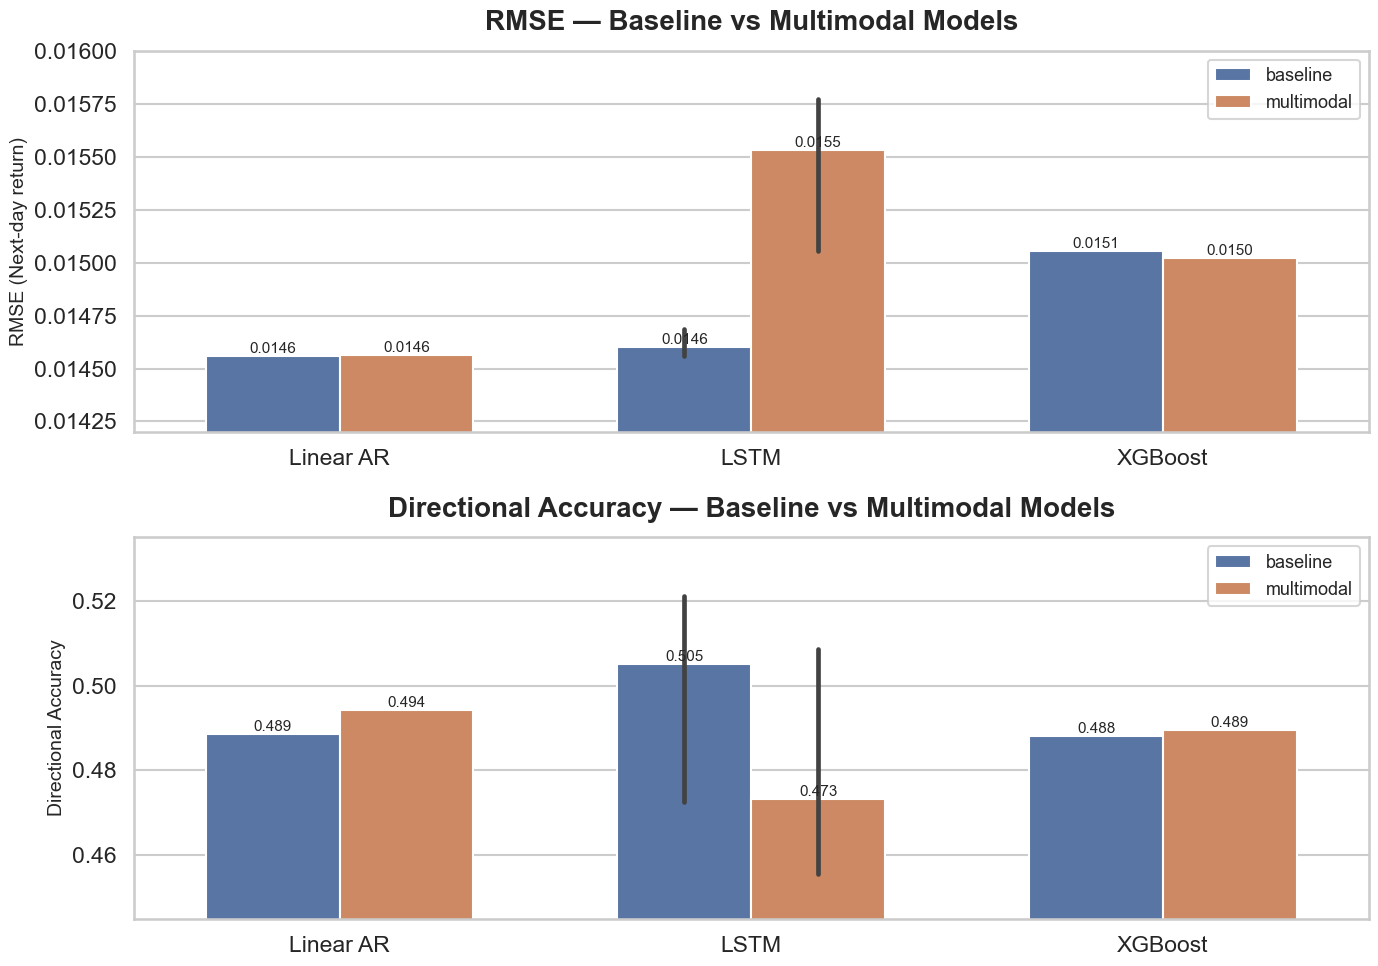

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", context="talk")

palette = ["#4C72B0", "#DD8452"]   # blue, orange (seaborn deep palette)
plt.figure(figsize=(14, 10))


# ------------------------------------------------------
# 1) RMSE Plot
# ------------------------------------------------------
plt.subplot(2, 1, 1)
ax1 = sns.barplot(
    data=results,
    x="family",
    y="RMSE",
    hue="type",
    palette=palette,
    width=0.65
)

plt.title("RMSE — Baseline vs Multimodal Models", fontsize=20, weight="bold", pad=15)
plt.xlabel("")
plt.ylabel("RMSE (Next-day return)", fontsize=14)

# add value labels
for p in ax1.patches:
    height = p.get_height()
    ax1.annotate(
        f"{height:.4f}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center", va="bottom",
        fontsize=11
    )

plt.legend(title="", fontsize=13)
plt.ylim(0.0142, 0.0160)


# ------------------------------------------------------
# 2) Directional Accuracy Plot
# ------------------------------------------------------
plt.subplot(2, 1, 2)
ax2 = sns.barplot(
    data=results,
    x="family",
    y="DirAcc",
    hue="type",
    palette=palette,
    width=0.65
)

plt.title("Directional Accuracy — Baseline vs Multimodal Models", fontsize=20, weight="bold", pad=15)
plt.xlabel("")
plt.ylabel("Directional Accuracy", fontsize=14)

for p in ax2.patches:
    height = p.get_height()
    ax2.annotate(
        f"{height:.3f}",
        (p.get_x() + p.get_width() / 2., height),
        ha="center", va="bottom",
        fontsize=11
    )

plt.legend(title="", fontsize=13)
plt.ylim(0.445, 0.535)

plt.tight_layout()
plt.show()


In [57]:
plt.savefig("../../figures/rmse_comparison.png", dpi=300, bbox_inches="tight")
plt.savefig("../../figures/diracc_comparison.png", dpi=300, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>

In [58]:
summary_pretty = summary_df.copy()
for col in summary_pretty.columns:
    if col != "Family":
        summary_pretty[col] = summary_pretty[col].round(6)

summary_pretty


,Family,RMSE_baseline,RMSE_mm,ΔRMSE,MAE_baseline,MAE_mm,ΔMAE,DirAcc_baseline,DirAcc_mm,ΔDirAcc,R2_baseline,R2_mm,ΔR2
0,LSTM,0.014728,0.014818,0.000090,0.009756,0.009852,0.000095,0.456286,0.526306,0.070019,-0.031059,-0.043671,-0.012612
1,Linear AR,0.014561,0.014563,0.000002,0.009733,0.009735,0.000001,0.488545,0.494364,0.005818,-0.014180,-0.014497,-0.000318
2,XGBoost,0.015056,0.015020,-0.000036,0.010149,0.010074,-0.000074,0.488182,0.489455,0.001273,-0.084375,-0.079155,0.005220


In [59]:
summary_pretty.to_csv("../results/overall_metrics_summary.csv", index=False)
